In [36]:
import numpy as np
import math as math
import matplotlib.pyplot as plt

In [37]:
nano_density = 2000 #kg/m^3 units

In [38]:
nano_diameter = 166*10**-9 # 166 nm in meters
print(nano_diameter, 'nanoparticle diameter in meters')

##diam to radius
nano_radius = nano_diameter/2
print(nano_radius, 'nanoparticle radius in meters')


##plugging in radius to volume
nano_volume = 4/3*math.pi*(nano_radius)**3
print(nano_volume, 'nanoparticle volume in kg/m^3')

##plugging in volume to find mass
nano_mass = nano_density * nano_volume
print(nano_mass, 'nanoparticle mass in kilograms')

nano_mass_ng = nano_mass * (1*10**12)
print(nano_mass_ng, ' nanoparticle mass in nanograms')

1.66e-07 nanoparticle diameter in meters
8.3e-08 nanoparticle radius in meters
2.3950957848241962e-21 nanoparticle volume in kg/m^3
4.790191569648393e-18 nanoparticle mass in kilograms
4.790191569648392e-06  nanoparticle mass in nanograms


# Charge calculations of 166 nm nanosphere, approximating as a conducting sphere where V_electrospray = 3kV

In [39]:
##Now onto charge calculations
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
es_voltage = 3000 #Voltages applied onto inkjet/electrospray

Q_ES_C= es_voltage*4*math.pi*epsilon*nano_radius #Coulombs
print(Q_ES_C, 'Coulombs')


##convert from Coulombs to elementary charges
elementary_charges_ES = Q_ES_C*(6.242*10**18)
print(elementary_charges_ES, 'elementary charges')

2.7704398709464493e-14 Coulombs
172930.85674447735 elementary charges


# Charge caluclations of 166 nm sphere, approximating as a confucting sphere where V_inkjet = 450 V

In [40]:
##Now onto charge calculations
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
IJ_voltage = 450 #Voltage applied onto inkjet

Q_IJ_C= IJ_voltage*4*math.pi*epsilon*nano_radius #Coulombs
print(Q_IJ_C, 'Coulombs')


##convert from Coulombs to elementary charges
elementary_charges_IJ = Q_IJ_C*(6.242*10**18)
print(elementary_charges_IJ, 'elementary charges')

4.155659806419674e-15 Coulombs
25939.628511671603 elementary charges


In [ ]:
Q_m_nano_1 = Q_ES_C/nano_mass
Q_m_nano_2 = Q_IJ_C/nano_mass


print('Q/m max',Q_m_nano_1, ' C/kg') ##this is using the electrospray, probably irrelevant 
print('Q/m min', Q_m_nano_2, ' C/kg')

Q/m max 5783.568006967629  C/kg
Q/m min 867.5352010451443  C/kg


In [42]:

# constants

epsilon = 8.854e-12        # vacuum permittivity (F/m)
rho_nano = 2000       # silica density (kg/m^3)


# trap parameters 


Vrf = 300               # RF voltage amplitude (V)
freq = 300              # RF frequency (Hz)
r0 = 4.4e-3             # trap radius (m)

# nanosphere potential relative to ground
Vd = 450                 # change if needed

# nanosphere diameter range
d_min = 1e-7 ##100 nm diameter
d_max = 1.66e-7 ##166 nm diameter nanosphere


# derived quantities


Omega = 2*np.pi*freq

def nanosphere_mass(radius):
    """Mass of nanosphere"""
    return (4/3)*np.pi*radius**3*rho_nano

def nanosphere_charge(radius):
    """Charge assuming conducting sphere"""
    return 4*np.pi*epsilon*radius*Vd

def trap_depth(q, m):
    """Pseudopotential trap depth (J)"""
    return (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

def mathieu_q(q, m):
    """Mathieu stability parameter"""
    return (2*q*Vrf)/(m*r0**2*Omega**2)


# calculate for nanosphere diameter range


for d in [d_min, d_max]:

    r = d/2
    m = nanosphere_mass(r)
    q = nanosphere_charge(r)
    Charge_to_mass_ratio = q/m


    U = trap_depth(q, m)
    qM = mathieu_q(q, m)

    print("Nanosphere diameter:", d*1e6, "um")
    print("Mass:", m, "kg")
    print("Mass:", m*1e12, "ng")
    print("Charge:", q, "C")
    print('Charge to mass ratio',Charge_to_mass_ratio, 'C/kg')
    print("Mathieu q:", qM)
    print("Trap depth:", U, "J")
    print("Trap depth:", U/1.602e-19, "eV")
    print()

Nanosphere diameter: 0.09999999999999999 um
Mass: 1.0471975511965976e-18 kg
Mass: 1.0471975511965976e-06 ng
Charge: 2.503409521939562e-15 C
Charge to mass ratio 2390.5799999999995 C/kg
Mathieu q: 20851.962395979666
Trap depth: 1.9575375454957942e-09 J
Trap depth: 12219335489.98623 eV

Nanosphere diameter: 0.166 um
Mass: 4.790191569648393e-18 kg
Mass: 4.790191569648392e-06 ng
Charge: 4.155659806419674e-15 C
Charge to mass ratio 867.5352010451443 C/kg
Mathieu q: 7567.12236753508
Trap depth: 1.1792394852384305e-09 J
Trap depth: 7361045475.895322 eV



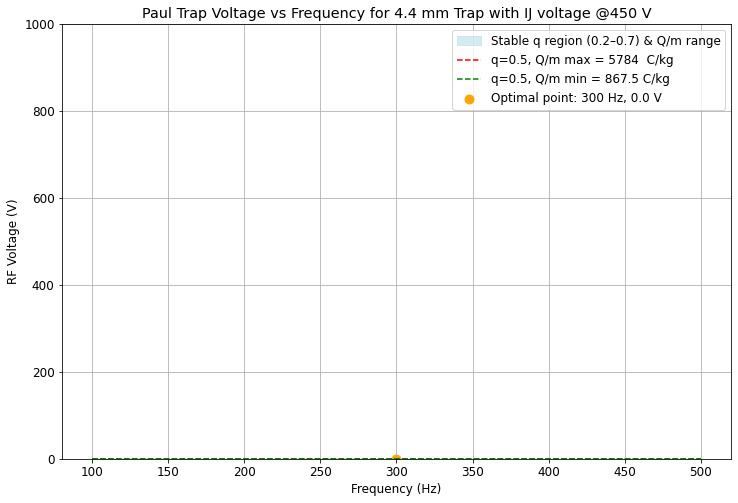

In [43]:

## Parameters 
r0 = 4.4e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 867.5352010451443 # C/kg
Q_m_max = 2390.5799999999995 # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max = 5784  C/kg')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min = 867.5 C/kg')


#plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
plt.ylim((0,1000))
plt.title('Paul Trap Voltage vs Frequency for 4.4 mm Trap with IJ voltage @450 V')

plt.legend()
plt.rcParams.update({'font.size': 12})
plt.grid(True)
plt.show()


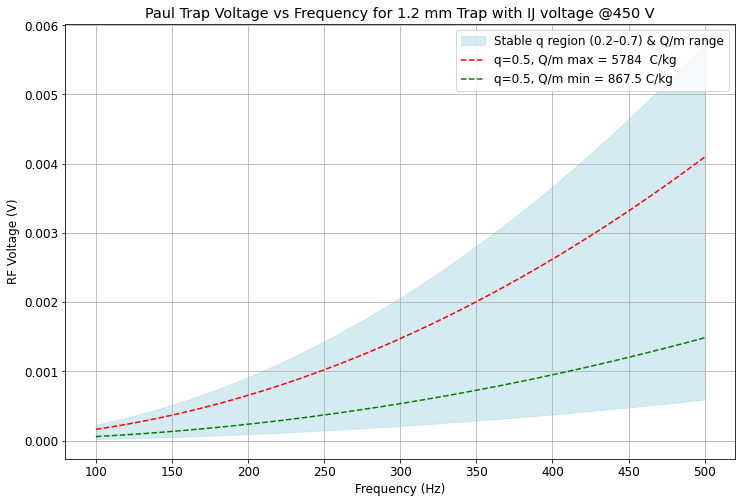

In [44]:

## Parameters 
r0 = 1.2e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m measured diameter range of 49-53 µm ethanol drops

Q_m_min = 867.5352010451443 # C/kg
Q_m_max = 2390.5799999999995 # C/kg


## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
# f_opt = 300  # Hz
# Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
# q_opt = 0.5
# V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max = 5784  C/kg')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min = 867.5 C/kg')


#plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

#plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
#plt.ylim((0,100))
plt.title('Paul Trap Voltage vs Frequency for 1.2 mm Trap with IJ voltage @450 V')

plt.legend()
plt.rcParams.update({'font.size': 12})
plt.grid(True)
plt.show()


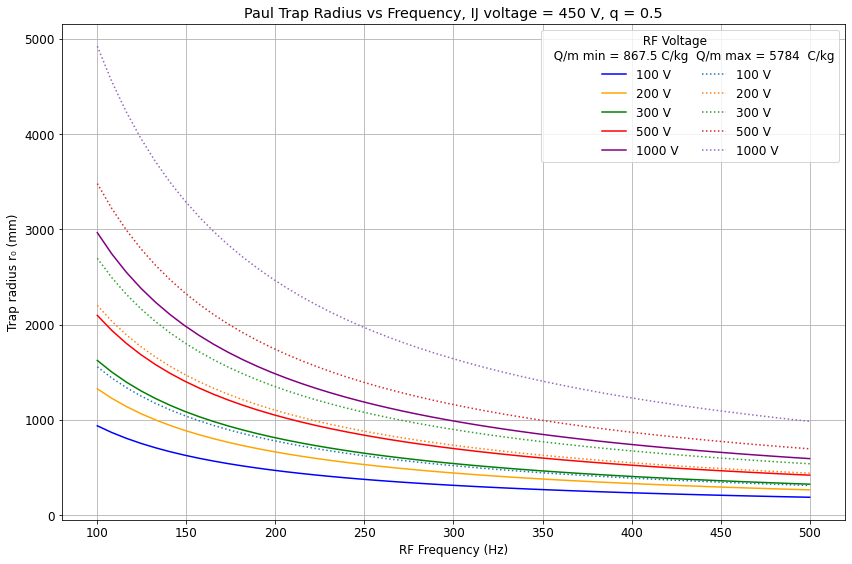

In [45]:
## Fixed parameters
Q_m_min = 867.5352010451443 # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

## RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # RF Drive voltage (aka voltage on the rods)
colors = ['blue','orange','green', 'red', 'purple'] 


## Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_min * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for i in range(0,5):
    V = voltages[i]
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V",color=colors[i])  # convert to mm


#second plots
Q_m_max = 2390.5799999999995 # C/kg 

# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * Q_m_max * V) / (q * (2*np.pi*f)**2))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V", alpha =1 , linestyle = 'dotted')  # convert to mm

plt_2 = plt
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency, IJ voltage = 450 V, q = 0.5")
plt.grid(True)
plt.legend(title='                         RF Voltage \n  Q/m min = 867.5 C/kg  Q/m max = 5784  C/kg', ncol=2)

plt.tight_layout()
plt.show()
plt_2.show()

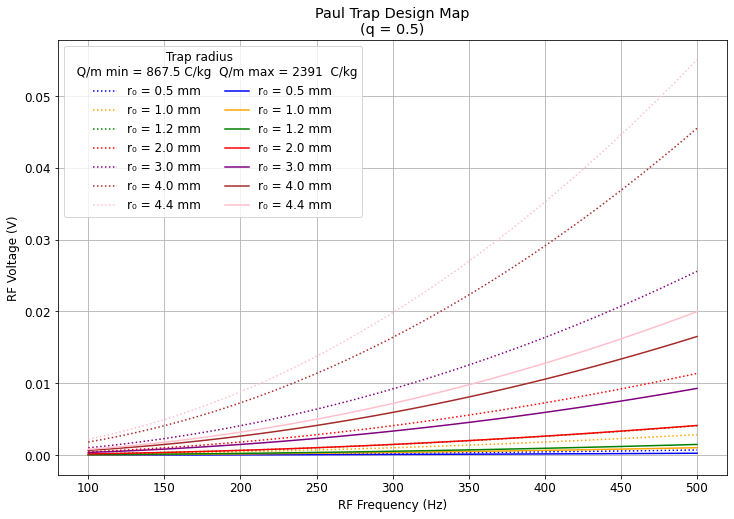

In [48]:

# Fixed parameters
Q_m_min = 867.5352010451443 # C/kg 
Q_m_max = 2390.5799999999995 
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

plt.figure(figsize=(12,8))

# Trap radii to plot (in mm) to compare
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]
colors = ['blue','orange','green', 'red', 'purple', 'brown', 'pink'] 

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_min)


i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i], linestyle = 'dotted')
    i=i+1


def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_max)

i=0
for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm", color=colors[i])
    i=i+1
    
#plt.figure(figsize=(12,8))
#plt.scatter(PT_freq_list,PT_volts_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
#plt.ylim(0,1500)
plt.title("Paul Trap Design Map\n(q = 0.5)")
plt.grid(True)

plt.rcParams.update({'font.size': 12})
plt.legend(title='                         Trap radius \n  Q/m min = 867.5 C/kg  Q/m max = 2391  C/kg', ncol=2)

#plt.tight_layout()
plt.show()


In [47]:

# constants

epsilon = 8.854e-12        # vacuum permittivity (F/m)
rho_nano = 2000       # silica density (kg/m^3)


# trap parameters 


Vrf = 300               # RF voltage amplitude (V)
freq = 300              # RF frequency (Hz)
r0 = 4.4e-3             # trap radius (m)

# nanosphere potential relative to ground
Vd = 450                 # change if needed

# nanosphere diameter range
d_min = 1e-7 ##100 nm diameter
d_max = 1.66e-7 ##166 nm diameter nanosphere


# derived quantities


Omega = 2*np.pi*freq

def nanosphere_mass(radius):
    """Mass of nanosphere"""
    return (4/3)*np.pi*radius**3*rho_nano

def nanosphere_charge(radius):
    """Charge assuming conducting sphere"""
    return 4*np.pi*epsilon*radius*Vd

def trap_depth(q, m):
    """Pseudopotential trap depth (J)"""
    return (q**2 * Vrf**2) / (4 * m * Omega**2 * r0**2)

def mathieu_q(q, m):
    """Mathieu stability parameter"""
    return (2*q*Vrf)/(m*r0**2*Omega**2)


# calculate for nanosphere diameter range


for d in [d_min, d_max]:

    r = d/2
    m = nanosphere_mass(r)
    q = nanosphere_charge(r)
    Charge_to_mass_ratio = q/m


    U = trap_depth(q, m)
    qM = mathieu_q(q, m)

    print("Nanosphere diameter:", d*1e6, "um")
    print("Mass:", m, "kg")
    print("Mass:", m*1e12, "ng")
    print("Charge:", q, "C")
    print('Charge to mass ratio',Charge_to_mass_ratio, 'C/kg')
    print("Mathieu q:", qM)
    print("Trap depth:", U, "J")
    print("Trap depth:", U/1.602e-19, "eV")
    print()

Nanosphere diameter: 0.09999999999999999 um
Mass: 1.0471975511965976e-18 kg
Mass: 1.0471975511965976e-06 ng
Charge: 2.503409521939562e-15 C
Charge to mass ratio 2390.5799999999995 C/kg
Mathieu q: 20851.962395979666
Trap depth: 1.9575375454957942e-09 J
Trap depth: 12219335489.98623 eV

Nanosphere diameter: 0.166 um
Mass: 4.790191569648393e-18 kg
Mass: 4.790191569648392e-06 ng
Charge: 4.155659806419674e-15 C
Charge to mass ratio 867.5352010451443 C/kg
Mathieu q: 7567.12236753508
Trap depth: 1.1792394852384305e-09 J
Trap depth: 7361045475.895322 eV

